# CODEX GBM (WangLab Visium HD) — HE cell-type preprocess

Join single-nuclei annotations (`cellID` / `cell_type` / `subcluster`) to microscope
pixel coordinates from `2_Single_Nuclei_Matrix/*_loc.csv`.

Three Hist2Pheno heads are built from `GBM_nuclei_primarySN_GD_annotation.xlsx`,
ordered by cell-type meaning:

| Nucleus column | Hierarchy column | Head | Typical n |
|----------------|------------------|------|-----------|
| `subcluster` | `celltype_level2` | L2 fine / `final_CT` | 16 trainable subtypes |
| `spatial_niche` | `celltype_level12` | L12 intermediate / `final_sublineage` | SN1–SN9; **drop LowQ and missing** |
| `cell_type` | `celltype_level1` | L1 coarse / `final_lineage` | Tumor / Myeloid / Lymph / Oligo / Vascular |

One workbook row is an *observed triple*. `Mac_SEPP1` maps to Myeloid (Rec) and
Vascular (Ini). Rows whose `cell_type` or `subcluster` is **Unknown / LowQ**
are dropped (they would otherwise become Unknown heads). `lowQ_vas` is kept.

Workbook:
`data/CODEX/GBM/WangLab/3_Annotation_Table/GBM_sc_seg_celltypes_hierarchy.xlsx`

`1_Bin` SpatialNiches has `Barcode`, not `cell_id`. Nucleus ↔ 16 µm bin links live in
`3_Mapping_bin_nuclei/` (`intersect_ratio`, `cell_area`, `SN`). This notebook attaches the
primary niche (max `intersect_ratio`) per nucleus.

Results CSVs (and therefore GT `h5ad`) drop nuclei whose `spatial_niche` is LowQ
or missing, and nuclei whose `cell_type` / `subcluster` is Unknown or LowQ, so
every remaining row has a 16 µm `bin_barcode` and a trainable triple. The source
`GBM_nuclei_primarySN_GD_annotation.xlsx` is left unchanged.

`loc.csv` `x,y` are already microscope HE pixels (same canvas as StarDist).


In [1]:
## 2026.09.09 LLY: hierarchy by cell-type meaning — subcluster→L2, SN→L12,
##            cell_type→L1; drop Unknown/LowQ rows from workbook and GT CSV
## 2026.09.08 LLY: GT Results CSV drops SN LowQ/missing so bin_barcode is always set
## 2026.09.08 LLY: hierarchy from nuclei xlsx (observed triples)
## 2026.09.07 LLY: spatial QC of GBM_nuclei_primarySN_GD_annotation.xlsx
## 2026.09.04 LLY: attach primary SN from 3_Mapping_bin_nuclei
## 2026.09.03 LLY: WangLab Visium HD Initial / Recurrent → Hist2Pheno
## Env: SeededNTM


In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "code/CODEX_gbm").is_dir() and (candidate / "data/CODEX/GBM").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the Hist2Pheno repository root")


REPO = find_repo_root()
GBM_DIR = REPO / "code" / "CODEX_gbm"
PKG_DIR = REPO / "code" / "Hist2Pheno_pkg"
for _p in (GBM_DIR, PKG_DIR):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

from gbm_paths import (
    DEFAULT_HIERARCHY_SHEET,
    DEFAULT_HIERARCHY_XLSX,
    DEFAULT_NUCLEI_SN_GD_XLSX,
    DEFAULT_RESULTS_DIR,
    GBM_EXCLUDED_CELLTYPES,
    GBM_EXCLUDED_SN,
    GBM_HIERARCHY_SOURCE_COLS,
    annotation_xlsx_path,
    bin_nuclei_mapping_xlsx_path,
    fill_gbm_spatial_niche,
    filter_usable_gbm_cell_labels,
    filter_usable_gbm_sn,
    is_excluded_gbm_cell_label,
    keep_gbm_spatial_niche,
    he_tif_path,
    load_gbm_celltype_hierarchy,
    loc_csv_path,
    normalize_gbm_cell_type,
    sample_config,
    sample_ids,
    stardist_csv_path,
)
from plotting_palettes import (
    Cell_Type_COLORS_CODEX_gbm_gd,
    Cell_Type_COLORS_CODEX_gbm_sn,
    get_palette,
)

DEFAULT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Annotation xlsx:", DEFAULT_NUCLEI_SN_GD_XLSX)
print("Hierarchy xlsx:", DEFAULT_HIERARCHY_XLSX)
print("Column map:", GBM_HIERARCHY_SOURCE_COLS)


Annotation xlsx: /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/GBM/WangLab/3_Annotation_Table/GBM_nuclei_primarySN_GD_annotation.xlsx
Hierarchy xlsx: /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/GBM/WangLab/3_Annotation_Table/GBM_sc_seg_celltypes_hierarchy.xlsx
Column map: {'subcluster': 'celltype_level2', 'spatial_niche': 'celltype_level12', 'cell_type': 'celltype_level1'}


## Build 3-level hierarchy from `GBM_nuclei_primarySN_GD_annotation.xlsx`

Map nucleus columns onto BRCA-style Hist2Pheno names and write
`GBM_sc_seg_celltypes_hierarchy.xlsx` sheet `Celltype`.

| Nucleus column | Excel column | Head |
|----------------|--------------|------|
| `subcluster` | `celltype_level2` | L2 / `final_CT` |
| `spatial_niche` | `celltype_level12` | L12 / `final_sublineage` |
| `cell_type` | `celltype_level1` | L1 / `final_lineage` |

One row per **observed triple**. Drop SN LowQ/missing and any row whose
`cell_type` or `subcluster` is **Unknown / LowQ**. `Mac_SEPP1` still has two
L1 parents (Ini Vascular vs Rec Myeloid).


In [3]:
SHEET_BY_SAMPLE = {
    "P174511_Initial": "Ini",
    "P179161_Recurrent": "Rec",
}
# L1 coarse = cell_type; L12 = SN; L2 fine = subcluster
L1_ORDER = ["Tumor", "Myeloid", "Lymph", "Oligo", "Vascular"]
L12_ORDER = [f"SN{i}" for i in range(1, 10)]
L2_ORDER = [
    "AC-like", "MES-like", "OC-like", "NPC-like", "G1S", "G2M",
    "Mac_Tmr", "Mac_SPP1", "Mac_other", "Mac_SEPP1",
    "Lymphocyte", "Oligodendrocyte",
    "Vascular", "CAF", "Collagen_fibrils", "lowQ_vas",
]
ANNO_HIER_COLS = ["cell_id", "cell_type", "subcluster", "spatial_niche"]


def _label_sort_key(order: list[str], value: object) -> tuple[int, str]:
    text = str(value)
    try:
        return (order.index(text), text)
    except ValueError:
        return (len(order), text)


assert DEFAULT_NUCLEI_SN_GD_XLSX.is_file(), DEFAULT_NUCLEI_SN_GD_XLSX

nuclei_frames = []
for sample in sample_ids():
    sheet = SHEET_BY_SAMPLE[sample]
    df = pd.read_excel(DEFAULT_NUCLEI_SN_GD_XLSX, sheet_name=sheet, usecols=ANNO_HIER_COLS)
    df = df.copy()
    df["sample"] = sample
    df["cell_type"] = df["cell_type"].map(normalize_gbm_cell_type)
    df["subcluster"] = df["subcluster"].map(
        lambda v: "LowQ" if pd.isna(v) or str(v).strip() in ("", "nan") else str(v).strip()
    )
    n_raw = len(df)
    keep_sn = df["spatial_niche"].map(keep_gbm_spatial_niche)
    n_drop_sn = int((~keep_sn).sum())
    df = df.loc[keep_sn].copy()
    df["spatial_niche"] = df["spatial_niche"].map(fill_gbm_spatial_niche)
    n_after_sn = len(df)
    df = filter_usable_gbm_cell_labels(df)
    n_drop_unknown = n_after_sn - len(df)
    nuclei_frames.append(df)
    print(
        f"{sample} sheet={sheet!r} n={n_raw:,} → keep SN {n_after_sn:,}  "
        f"(drop LowQ/missing SN {n_drop_sn:,}; drop Unknown/LowQ {n_drop_unknown:,})  "
        f"L2={df['subcluster'].nunique()}  L12={df['spatial_niche'].nunique()}  "
        f"L1={df['cell_type'].nunique()}"
    )

nuclei = pd.concat(nuclei_frames, ignore_index=True)

# subcluster → L2, spatial_niche → L12, cell_type → L1
counts = (
    nuclei.groupby(["cell_type", "subcluster", "spatial_niche", "sample"])
    .size()
    .unstack("sample", fill_value=0)
)
for sample in sample_ids():
    if sample not in counts.columns:
        counts[sample] = 0
counts = counts.rename(columns={
    "P174511_Initial": "n_Ini",
    "P179161_Recurrent": "n_Rec",
})
counts["n_total"] = counts["n_Ini"] + counts["n_Rec"]
hierarchy_xlsx = counts.reset_index().rename(columns=GBM_HIERARCHY_SOURCE_COLS)

parents = (
    nuclei.groupby("subcluster")["cell_type"]
    .nunique()
    .rename("n_cell_type")
)
conflict = parents[parents > 1].index.tolist()
notes = []
for row in hierarchy_xlsx.itertuples(index=False):
    note = []
    if row.celltype_level2 in conflict:
        note.append(
            f"{row.celltype_level2} maps to multiple cell_type values (Ini vs Rec)"
        )
    notes.append("; ".join(note) if note else pd.NA)
hierarchy_xlsx["note"] = notes

hierarchy_xlsx["_k1"] = hierarchy_xlsx["celltype_level1"].map(
    lambda v: _label_sort_key(L1_ORDER, v)
)
hierarchy_xlsx["_k2"] = hierarchy_xlsx["celltype_level2"].map(
    lambda v: _label_sort_key(L2_ORDER, v)
)
hierarchy_xlsx["_k12"] = hierarchy_xlsx["celltype_level12"].map(
    lambda v: _label_sort_key(L12_ORDER, v)
)
hierarchy_xlsx = (
    hierarchy_xlsx.sort_values(["_k1", "_k2", "_k12"])
    .drop(columns=["_k1", "_k2", "_k12"])
    .reset_index(drop=True)
)
out_cols = [
    "celltype_level1", "celltype_level12", "celltype_level2",
    "n_Ini", "n_Rec", "n_total", "note",
]
hierarchy_xlsx = hierarchy_xlsx[out_cols]

print("\nWrote mapping: subcluster → celltype_level2, "
      "spatial_niche → celltype_level12, cell_type → celltype_level1")
print(
    f"Observed triples: {len(hierarchy_xlsx):,}  "
    f"L2={hierarchy_xlsx['celltype_level2'].nunique()}  "
    f"L12={hierarchy_xlsx['celltype_level12'].nunique()}  "
    f"L1={hierarchy_xlsx['celltype_level1'].nunique()}"
)
print("\nL1 cell_type × L2 subcluster (n_total):")
print(
    hierarchy_xlsx.pivot_table(
        index="celltype_level1", columns="celltype_level2",
        values="n_total", aggfunc="sum", fill_value=0,
    ).to_string()
)
print("\nL12 spatial_niche counts:")
print(
    hierarchy_xlsx.groupby("celltype_level12")["n_total"].sum()
    .reindex(L12_ORDER)
    .dropna()
    .astype(int)
    .to_string()
)

join_rules = pd.DataFrame({
    "rule": [
        "Source: GBM_nuclei_primarySN_GD_annotation.xlsx sheets Ini / Rec.",
        "subcluster → celltype_level2 (Hist2Pheno L2 / final_CT).",
        "spatial_niche → celltype_level12 (L12 / final_sublineage).",
        "cell_type → celltype_level1 (L1 / final_lineage).",
        "One row per observed (cell_type, subcluster, spatial_niche) triple.",
        "Drop spatial_niche LowQ/missing; drop Unknown/LowQ on cell_type and subcluster.",
        "lowQ_vas is kept (vascular subtype, not the Unknown/LowQ drop list).",
        "Mac_SEPP1: Ini Vascular vs Rec Myeloid — both triples are kept.",
    ]
})

DEFAULT_HIERARCHY_XLSX.parent.mkdir(parents=True, exist_ok=True)
with pd.ExcelWriter(DEFAULT_HIERARCHY_XLSX, engine="openpyxl") as writer:
    hierarchy_xlsx.to_excel(writer, sheet_name=DEFAULT_HIERARCHY_SHEET, index=False)
    join_rules.to_excel(writer, sheet_name="join_rules", index=False)
print("\nSaved", DEFAULT_HIERARCHY_XLSX)

hierarchy_all = load_gbm_celltype_hierarchy(drop_excluded=False)
hierarchy = load_gbm_celltype_hierarchy(drop_excluded=True)
print(
    f"\nReloaded all: rows={len(hierarchy_all):,}  "
    f"L2={hierarchy_all['celltype_level2'].nunique()}  "
    f"L12={hierarchy_all['celltype_level1'].nunique()}  "
    f"L1={hierarchy_all['celltype_level0'].nunique()}  "
    f"L1 classes={sorted(hierarchy_all['celltype_level0'].unique())}"
)
print(
    f"Trainable (drop {GBM_EXCLUDED_CELLTYPES} on all heads): rows={len(hierarchy):,}  "
    f"L2={hierarchy['celltype_level2'].nunique()}  "
    f"L12={hierarchy['celltype_level1'].nunique()}  "
    f"L1={hierarchy['celltype_level0'].nunique()}  "
    f"{sorted(hierarchy['celltype_level0'].unique())}"
)
print("\nTrainable head (first 20 rows; loader aliases L12→level1, L1→level0):")
print(hierarchy.head(20).to_string(index=False))


P174511_Initial sheet='Ini' n=53,305 → keep SN 40,818  (drop LowQ/missing SN 12,487; drop Unknown/LowQ 3,447)  L2=13  L12=6  L1=5
P179161_Recurrent sheet='Rec' n=160,098 → keep SN 141,064  (drop LowQ/missing SN 19,034; drop Unknown/LowQ 3,225)  L2=16  L12=7  L1=5

Wrote mapping: subcluster → celltype_level2, spatial_niche → celltype_level12, cell_type → celltype_level1
Observed triples: 140  L2=16  L12=9  L1=5

L1 cell_type × L2 subcluster (n_total):
celltype_level2  AC-like   CAF  Collagen_fibrils    G1S    G2M  Lymphocyte  MES-like  Mac_SEPP1  Mac_SPP1  Mac_Tmr  Mac_other  NPC-like  OC-like  Oligodendrocyte  Vascular  lowQ_vas
celltype_level1                                                                                                                                                                      
Lymph                  0     0                 0      0      0        1434         0          0         0        0          0         0        0                0         0         0

## Join annotation + loc + primary spatial niche; write Results CSVs

Per sample: `cellID` ↔ loc `id`, fill empty Ini `subcluster` as `LowQ`, strip Rec
`cell_type` prefixes, then attach the WangLab bin–nuclei row with the largest
`intersect_ratio`. A nucleus can overlap several 16 µm bins; only the primary
niche is stored on the Results CSV. Rows whose `spatial_niche` is **LowQ or missing**,
or whose `cell_type` / `subcluster` is **Unknown / LowQ**, are dropped here (same
rule as the hierarchy workbook), so `bin_barcode` is always set and no Unknown head
is written for the GT `h5ad` step.


  bin–nuclei mapping: 73,055 overlaps → 44,964 nuclei (0917_200G_celltype_spatialNiches_mapping_Ini.xlsx)

P174511_Initial
  annotation n=53,305  loc n=134,393  joined=53,305
  HE TIFF 38976x16128  inside=53,305/53,305
  usable SN (not LowQ/missing): 40,818/53,305  dropped=12,487
  GT CSV after drop SN LowQ/missing: 40,818; after drop Unknown/LowQ: 37,371  bin_barcode all set=True
  L1 cell_type: {'Tumor': 23480, 'Myeloid': 7529, 'Vascular': 3586, 'Oligo': 1997, 'Lymph': 779}
  L2 subcluster: {'MES-like': 12736, 'AC-like': 6009, 'OC-like': 4735, 'Mac_Tmr': 3801, 'Mac_SPP1': 2405, 'Oligodendrocyte': 1997, 'CAF': 1893, 'Mac_other': 1323, 'Lymphocyte': 779, 'Vascular': 664, 'Mac_SEPP1': 398, 'lowQ_vas': 322, 'Collagen_fibrils': 309}
  L12 spatial_niche: {'SN2': 25215, 'SN1': 5394, 'SN5': 4594, 'SN6': 1040, 'SN8': 973, 'SN9': 155}
  L1 cell_type × L2 subcluster:
subcluster  AC-like   CAF  Collagen_fibrils  Lymphocyte  MES-like  Mac_SEPP1  Mac_SPP1  Mac_Tmr  Mac_other  OC-like  Oligodendroc

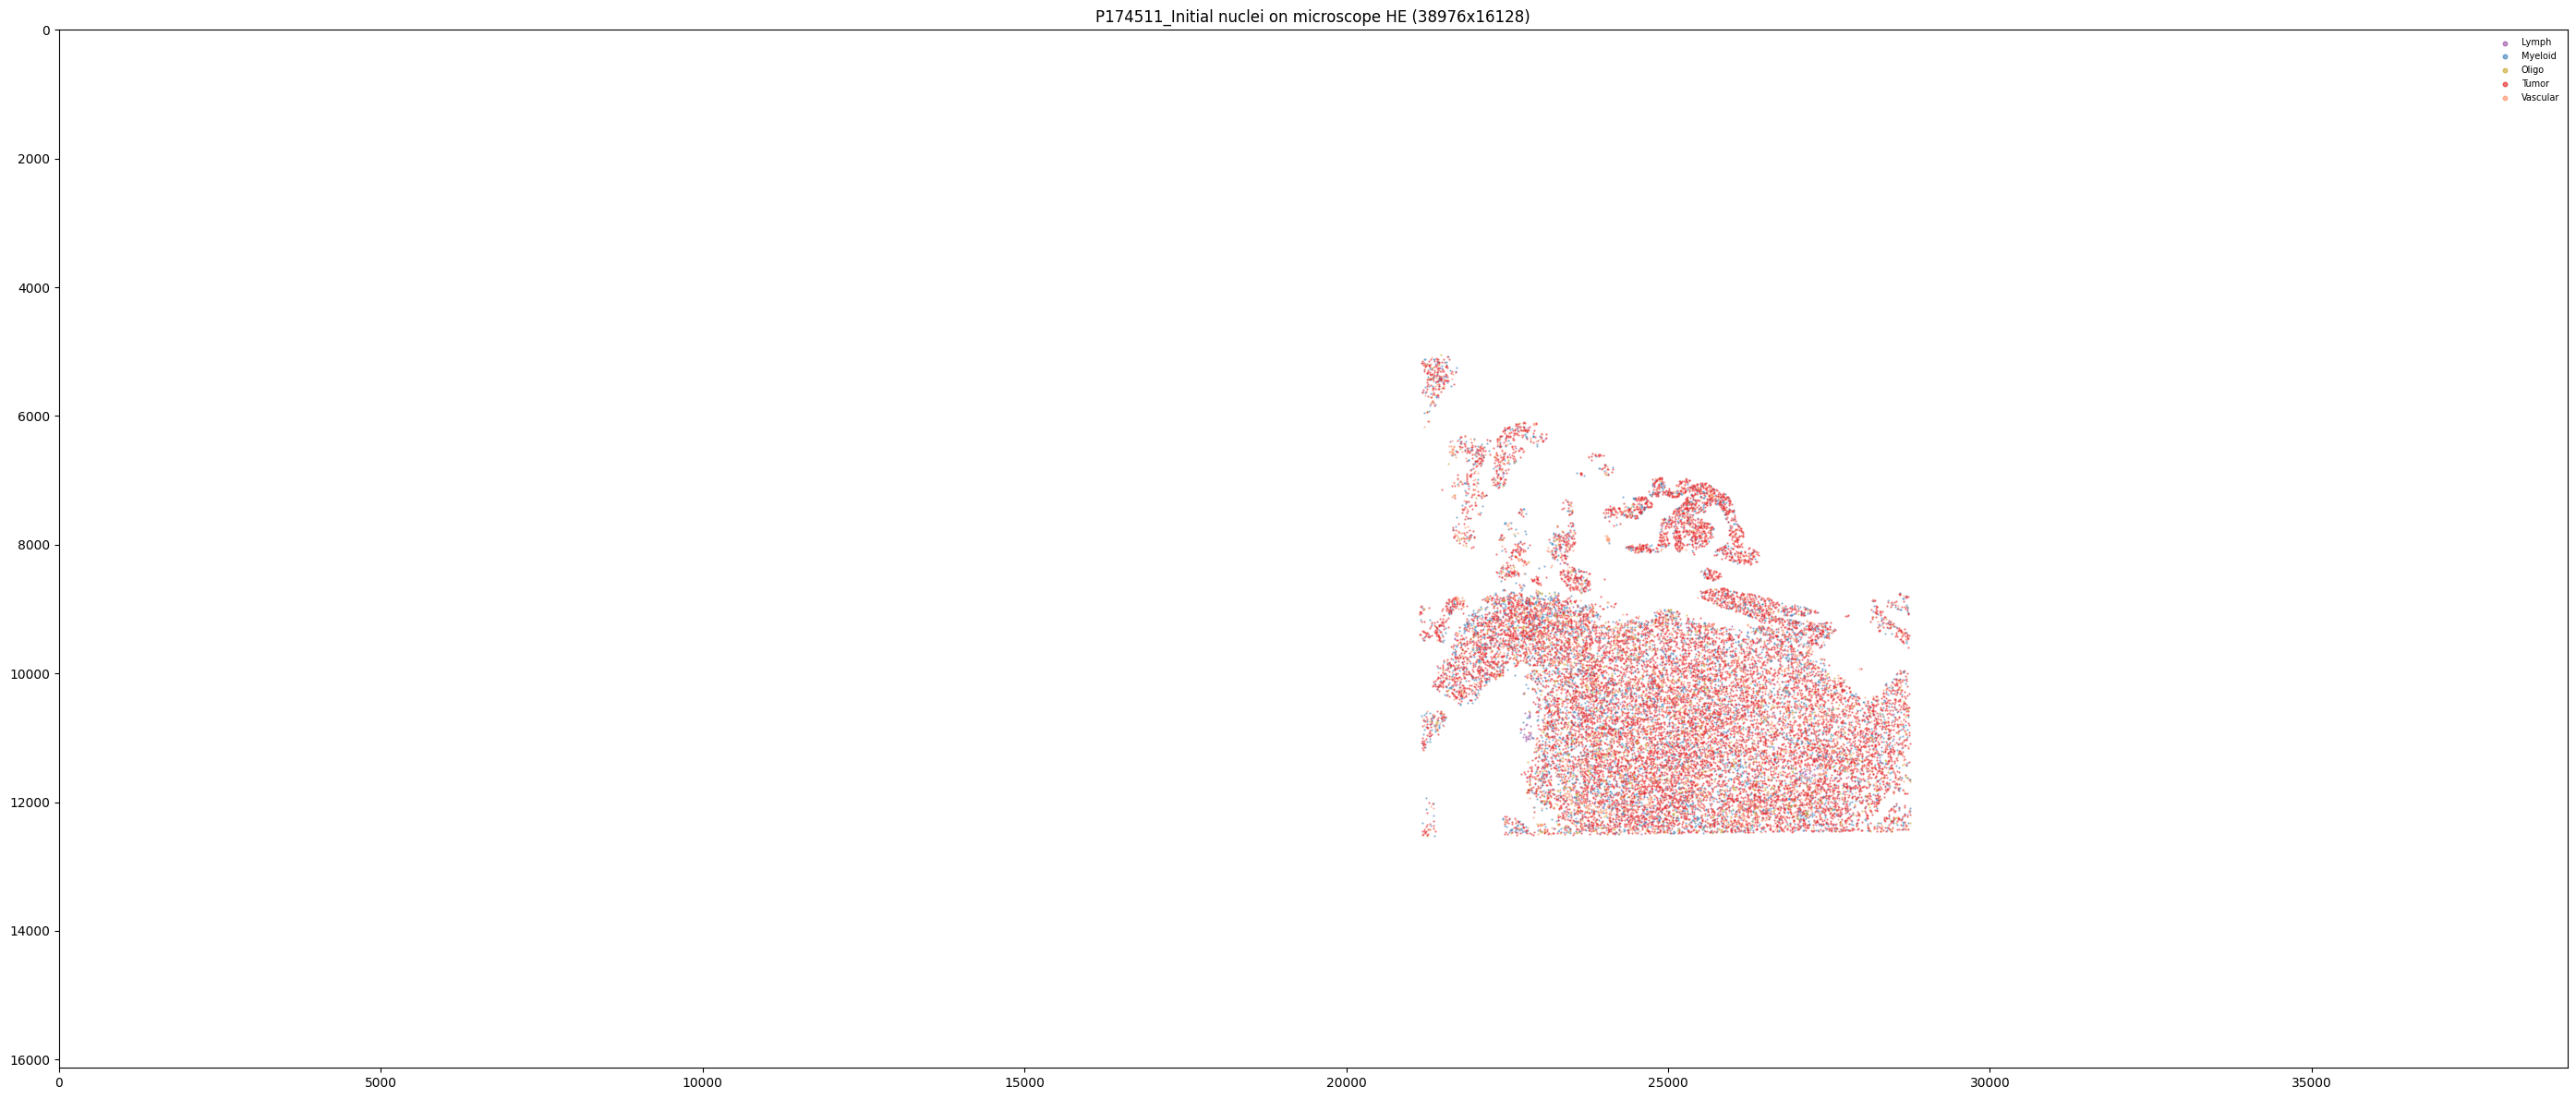

  QC fig /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/GBM/Results/figures/gbm_P174511_Initial_celltype_on_HE_qc.png
  bin–nuclei mapping: 232,568 overlaps → 141,064 nuclei (0917_200G_celltype_spatialNiches_mapping_Rec.xlsx)

P179161_Recurrent
  annotation n=160,098  loc n=812,831  joined=160,098
  HE TIFF 57600x24000  inside=160,098/160,098
  usable SN (not LowQ/missing): 141,064/160,098  dropped=19,034
  GT CSV after drop SN LowQ/missing: 141,064; after drop Unknown/LowQ: 137,839  bin_barcode all set=True
  L1 cell_type: {'Tumor': 99429, 'Myeloid': 19269, 'Vascular': 10879, 'Oligo': 7607, 'Lymph': 655}
  L2 subcluster: {'OC-like': 23677, 'G1S': 19453, 'AC-like': 17657, 'G2M': 16142, 'MES-like': 12441, 'Mac_Tmr': 11026, 'NPC-like': 10059, 'Oligodendrocyte': 7607, 'CAF': 6418, 'Mac_other': 5034, 'Vascular': 2332, 'Mac_SEPP1': 1898, 'Mac_SPP1': 1311, 'Collagen_fibrils': 1170, 'lowQ_vas': 959, 'Lymphocyte': 655}
  L12 spatial_niche: {'SN1': 66732, 'SN2': 27342, 'SN3': 17953, 'SN5'

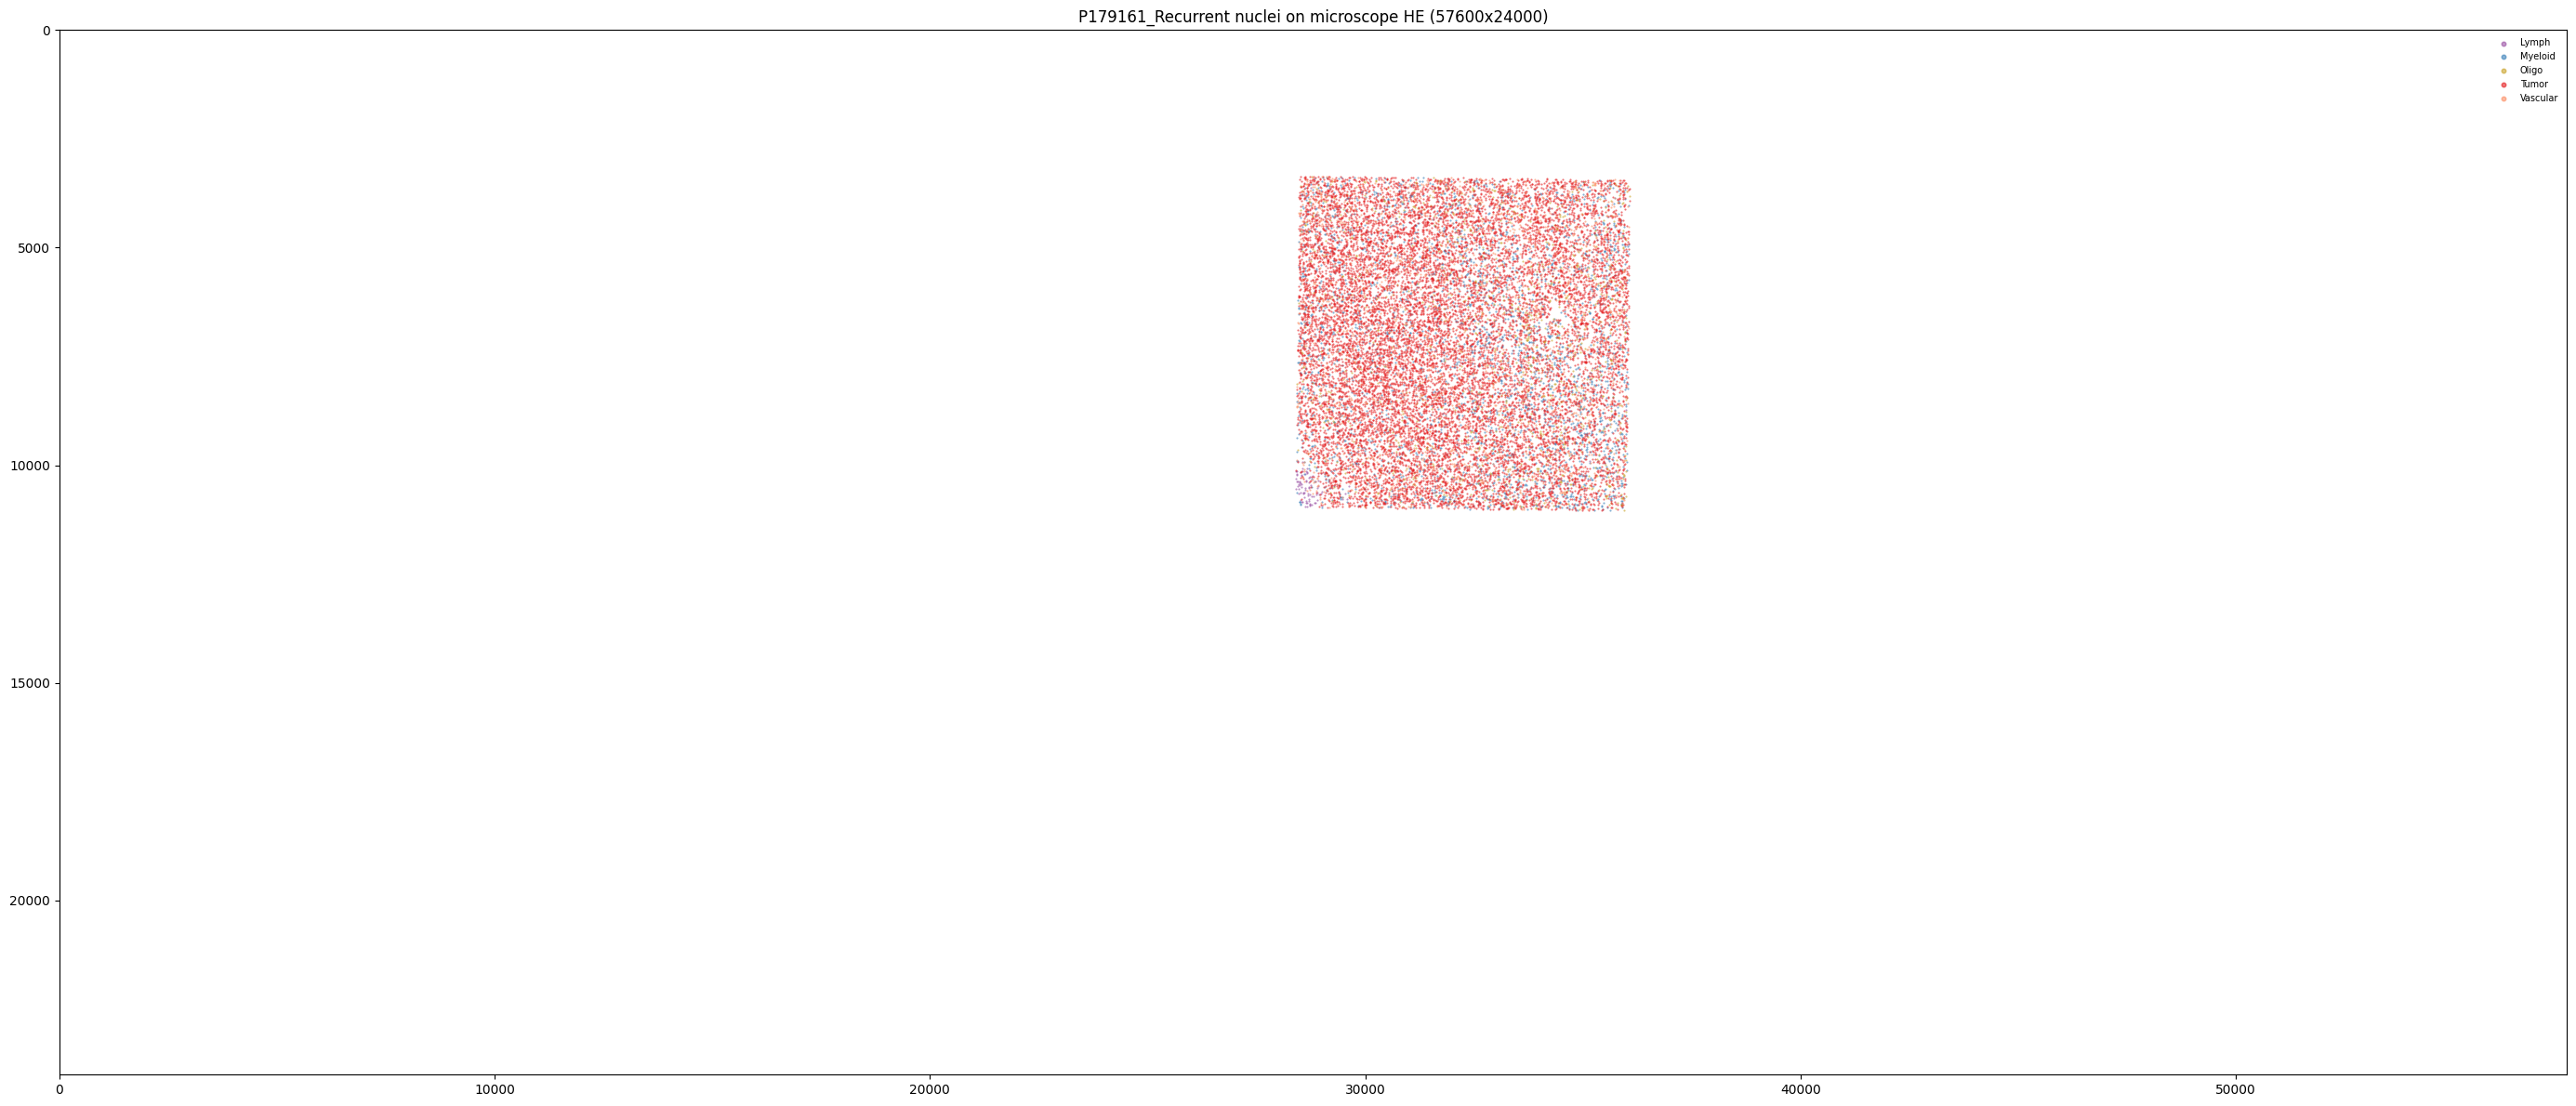

  QC fig /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/GBM/Results/figures/gbm_P179161_Recurrent_celltype_on_HE_qc.png


In [4]:
ANNO_USECOLS = ["cellID", "cell_type", "subcluster"]
MAP_USECOLS = ["cell_id", "index", "SN", "intersect_ratio", "cell_area"]
HIER_TRIPLES = set(
    zip(
        hierarchy_all["celltype_level2"],
        hierarchy_all["celltype_level1"],
        hierarchy_all["celltype_level0"],
    )
)
L1_COLORS = get_palette("codex_gbm", "coarse", rgba=False)


def _fill_subcluster(value: object) -> str:
    if pd.isna(value) or str(value).strip() in ("", "nan"):
        return "LowQ"
    return str(value).strip()


def load_primary_bin_mapping(sample: str) -> pd.DataFrame:
    path = bin_nuclei_mapping_xlsx_path(sample)
    mapping = pd.read_excel(path, usecols=MAP_USECOLS)
    mapping["cell_id"] = mapping["cell_id"].astype(str).str.strip()
    n_rows = len(mapping)
    n_cells = mapping["cell_id"].nunique()
    mapping = (
        mapping.sort_values("intersect_ratio", ascending=False)
        .drop_duplicates("cell_id", keep="first")
        .rename(
            columns={
                "index": "bin_barcode",
                "SN": "spatial_niche",
                "intersect_ratio": "sn_intersect_ratio",
                "cell_area": "sn_cell_area",
            }
        )
    )
    print(
        f"  bin–nuclei mapping: {n_rows:,} overlaps → {n_cells:,} nuclei "
        f"({path.name})"
    )
    return mapping


def process_sample(sample: str, *, write: bool = True, plot: bool = True) -> pd.DataFrame:
    cfg = sample_config(sample)
    anno = pd.read_excel(annotation_xlsx_path(sample), usecols=ANNO_USECOLS)
    loc = pd.read_csv(loc_csv_path(sample))
    miss = {"cellID", "cell_type", "subcluster"} - set(anno.columns)
    if miss:
        raise KeyError(f"{sample} annotation missing {miss}")
    miss = {"id", "x", "y"} - set(loc.columns)
    if miss:
        raise KeyError(f"{sample} loc missing {miss}")

    anno = anno.copy()
    anno["cell_id"] = anno["cellID"].astype(str).str.strip()
    anno["cell_type_raw"] = anno["cell_type"]
    anno["cell_type"] = anno["cell_type"].map(normalize_gbm_cell_type)
    anno["subcluster"] = anno["subcluster"].map(_fill_subcluster)
    loc = loc.copy()
    loc["cell_id"] = loc["id"].astype(str).str.strip()
    merged = anno.merge(
        loc[["cell_id", "x", "y"]], on="cell_id", how="inner", validate="one_to_one"
    )
    merged["x_centroid"] = merged["x"].astype(float)
    merged["y_centroid"] = merged["y"].astype(float)
    merged["X_pix_HE"] = merged["x_centroid"]
    merged["Y_pix_HE"] = merged["y_centroid"]
    merged["sample"] = sample

    mapping = load_primary_bin_mapping(sample)
    merged = merged.merge(mapping, on="cell_id", how="left")

    he = he_tif_path(sample)
    with tifffile.TiffFile(he) as tiff:
        h, w = tiff.pages[0].shape[:2]
    inside = (
        (merged["X_pix_HE"] >= 0)
        & (merged["X_pix_HE"] < w)
        & (merged["Y_pix_HE"] >= 0)
        & (merged["Y_pix_HE"] < h)
    )
    n_joined = len(merged)
    n_sn = int(merged["spatial_niche"].map(keep_gbm_spatial_niche).sum())
    print(f"\n{sample}")
    print(f"  annotation n={len(anno):,}  loc n={len(loc):,}  joined={n_joined:,}")
    print(f"  HE TIFF {w}x{h}  inside={inside.sum():,}/{n_joined:,}")
    print(
        f"  usable SN (not LowQ/missing): {n_sn:,}/{n_joined:,}  "
        f"dropped={n_joined - n_sn:,}"
    )
    merged = filter_usable_gbm_sn(merged)
    n_after_sn = len(merged)
    merged = filter_usable_gbm_cell_labels(merged)
    print(
        f"  GT CSV after drop SN LowQ/missing: {n_after_sn:,}; "
        f"after drop Unknown/LowQ: {len(merged):,}  "
        f"bin_barcode all set={bool(merged['bin_barcode'].map(lambda v: pd.notna(v) and str(v).strip() not in ('', 'nan')).all())}"
    )
    sn_filled = merged["spatial_niche"].map(fill_gbm_spatial_niche)
    unknown_triple = merged.loc[
        ~pd.Series(
            list(zip(merged["subcluster"], sn_filled, merged["cell_type"])),
            index=merged.index,
        ).isin(HIER_TRIPLES)
    ]
    parent_mismatch = (
        merged.groupby("subcluster")["cell_type"].nunique().loc[lambda s: s > 1]
    )
    print(f"  L1 cell_type: {merged['cell_type'].value_counts().to_dict()}")
    print(f"  L2 subcluster: {merged['subcluster'].value_counts().to_dict()}")
    print(f"  L12 spatial_niche: {merged['spatial_niche'].value_counts(dropna=False).to_dict()}")
    print("  L1 cell_type × L2 subcluster:")
    print(
        pd.crosstab(merged["cell_type"], merged["subcluster"], dropna=False)
        .to_string()
    )
    if len(unknown_triple):
        print(f"  WARNING triples not in hierarchy: {len(unknown_triple):,}")
    if len(parent_mismatch):
        print(
            "  subcluster with >1 cell_type (expected Mac_SEPP1 Ini Vascular vs Rec Myeloid):"
        )
        print(parent_mismatch.rename("n_cell_type").to_string())
    star = stardist_csv_path(sample)
    if star.is_file():
        star_n = sum(1 for _ in open(star, encoding="utf-8")) - 1
        print(f"  StarDist CSV n={star_n:,}  ({star.name})")

    out_cols = [
        "cell_id", "sample", "cell_type", "cell_type_raw", "subcluster",
        "spatial_niche", "bin_barcode", "sn_intersect_ratio", "sn_cell_area",
        "x_centroid", "y_centroid", "X_pix_HE", "Y_pix_HE",
    ]
    out = merged[out_cols].copy()
    out_path = Path(cfg["cell_info_csv"])
    if write:
        out.to_csv(out_path, index=False)
        print(f"  wrote {out_path}")

    if plot:
        fig, ax = plt.subplots(figsize=(10*3, 4*3))
        rng = np.random.default_rng(0)
        idx = rng.choice(len(out), size=min(20000, len(out)), replace=False)
        sc = out.iloc[idx]
        for ct, g in sc.groupby("cell_type"):
            ax.scatter(
                g["X_pix_HE"],
                g["Y_pix_HE"],
                s=0.3,
                label=ct,
                alpha=0.6,
                c=[L1_COLORS.get(str(ct), "#7f7f7f")],
            )
        ax.set_xlim(0, w)
        ax.set_ylim(h, 0)
        ax.set_aspect("equal")
        ax.set_title(f"{sample} nuclei on microscope HE ({w}x{h})")
        ax.legend(markerscale=6, fontsize=7, loc="upper right", frameon=False)
        fig.tight_layout()
        fig_dir = DEFAULT_RESULTS_DIR / "figures"
        fig_dir.mkdir(parents=True, exist_ok=True)
        fig_path = fig_dir / f"gbm_{sample}_celltype_on_HE_qc.png"
        fig.savefig(fig_path, dpi=300)
        plt.show()
        print(f"  QC fig {fig_path}")
    return out


sample_tables = {}
for sample in sample_ids():
    sample_tables[sample] = process_sample(sample, write=True, plot=True)


## Union class counts vs hierarchy

Confirm Ini+Rec `subcluster` / `spatial_niche` / `cell_type` match the three-level hierarchy workbook (L2 / L12 / L1). Results tables have already dropped SN LowQ/missing and Unknown/LowQ cell labels, so `bin_barcode` should be complete.


In [5]:
pooled = pd.concat(sample_tables.values(), ignore_index=True)
print(f"Pooled nuclei: {len(pooled):,}")
print("\nL2 subcluster (union)")
print(pooled["subcluster"].value_counts(dropna=False).to_string())
print("\nL12 spatial_niche (union)")
print(pooled["spatial_niche"].value_counts(dropna=False).to_string())
print("\nL1 cell_type (union)")
print(pooled["cell_type"].value_counts(dropna=False).to_string())

l2_data = set(pooled["subcluster"].dropna())
l12_data = set(pooled.loc[pooled["spatial_niche"].map(keep_gbm_spatial_niche), "spatial_niche"])
l1_data = set(pooled["cell_type"].dropna())
n_sn_drop = int((~pooled["spatial_niche"].map(keep_gbm_spatial_niche)).sum())
n_unknown = int(
    pooled["cell_type"].map(is_excluded_gbm_cell_label).sum()
    + pooled["subcluster"].map(is_excluded_gbm_cell_label).sum()
)
l2_hier = set(hierarchy_all["celltype_level2"])
l12_hier = set(hierarchy_all["celltype_level1"])
l1_hier = set(hierarchy_all["celltype_level0"])
print(f"\nL2 data {sorted(l2_data)}  hierarchy {sorted(l2_hier)}")
print(f"L2 only in data: {sorted(l2_data - l2_hier)}  only in hierarchy: {sorted(l2_hier - l2_data)}")
print(f"L12 only in data: {sorted(l12_data - l12_hier)}  only in hierarchy: {sorted(l12_hier - l12_data)}")
print(f"L1 only in data: {sorted(l1_data - l1_hier)}  only in hierarchy: {sorted(l1_hier - l1_data)}")
print(
    f"usable SN {pooled['spatial_niche'].map(keep_gbm_spatial_niche).sum():,}/{len(pooled):,}  "
    f"(drop LowQ/missing {n_sn_drop:,}; expect 0 after GT filter)"
)
print(f"Unknown/LowQ cell labels remaining: {n_unknown:,} (expect 0 after GT filter)")
n_barcode_ok = int(
    pooled["bin_barcode"].map(
        lambda v: pd.notna(v) and str(v).strip() not in ("", "nan")
    ).sum()
)
print(f"bin_barcode set: {n_barcode_ok:,}/{len(pooled):,}")


Pooled nuclei: 175,210

L2 subcluster (union)
subcluster
OC-like             28412
MES-like            25177
AC-like             23666
G1S                 19453
G2M                 16142
Mac_Tmr             14827
NPC-like            10059
Oligodendrocyte      9604
CAF                  8311
Mac_other            6357
Mac_SPP1             3716
Vascular             2996
Mac_SEPP1            2296
Collagen_fibrils     1479
Lymphocyte           1434
lowQ_vas             1281

L12 spatial_niche (union)
spatial_niche
SN1    72126
SN2    52557
SN5    17994
SN3    17953
SN4     7433
SN6     4917
SN7     1102
SN8      973
SN9      155

L1 cell_type (union)
cell_type
Tumor       122909
Myeloid      26798
Vascular     14465
Oligo         9604
Lymph         1434

L2 data ['AC-like', 'CAF', 'Collagen_fibrils', 'G1S', 'G2M', 'Lymphocyte', 'MES-like', 'Mac_SEPP1', 'Mac_SPP1', 'Mac_Tmr', 'Mac_other', 'NPC-like', 'OC-like', 'Oligodendrocyte', 'Vascular', 'lowQ_vas']  hierarchy ['AC-like', 'CAF', 'Collagen

## Spatial QC: `GBM_nuclei_primarySN_GD_annotation.xlsx`

Load the nucleus-level table (one row per `cell_id`) and plot on microscope HE pixels from `*_loc.csv`.

- **L2** `subcluster` (`celltype_level2`)
- **L12** `spatial_niche` (`celltype_level12`; SN1–SN9; LowQ / missing drawn as unlabeled)
- **L1** `cell_type` (`celltype_level1`)
- **GD** Rec only (`1104_Rec_HD_GD_Label.txt` via 8 µm → 16 µm parent)

Unlabeled SN / GD nuclei are drawn in light gray underneath.


In [6]:
from matplotlib.lines import Line2D

FIG_DIR = DEFAULT_RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SHEET_BY_SAMPLE = {
    "P174511_Initial": "Ini",
    "P179161_Recurrent": "Rec",
}
L1_COLORS = get_palette("codex_gbm", "coarse", rgba=False)
L2_COLORS = get_palette("codex_gbm", "fine", rgba=False)
SN_COLORS = get_palette("codex_gbm", "intermediate", rgba=False)
GD_COLORS = dict(Cell_Type_COLORS_CODEX_gbm_gd)
UNLABELED_COLOR = "#e6e6e6"

print("Annotation xlsx:", DEFAULT_NUCLEI_SN_GD_XLSX)
assert DEFAULT_NUCLEI_SN_GD_XLSX.is_file(), DEFAULT_NUCLEI_SN_GD_XLSX

anno_xy = {}
he_shape = {}
for sample in sample_ids():
    sheet = SHEET_BY_SAMPLE[sample]
    df = pd.read_excel(DEFAULT_NUCLEI_SN_GD_XLSX, sheet_name=sheet)
    df["cell_id"] = df["cell_id"].astype(str).str.strip()
    loc = pd.read_csv(loc_csv_path(sample), usecols=["id", "x", "y"])
    loc["cell_id"] = loc["id"].astype(str).str.strip()
    merged = df.merge(loc[["cell_id", "x", "y"]], on="cell_id", how="left")
    n_xy = merged["x"].notna().sum()
    with tifffile.TiffFile(he_tif_path(sample)) as tiff:
        h, w = tiff.pages[0].shape[:2]
    he_shape[sample] = (w, h)
    anno_xy[sample] = merged
    print(f"\n{sample}  sheet={sheet!r}  n={len(merged):,}  with xy={n_xy:,}  HE={w}x{h}")
    for col in ("cell_type", "subcluster", "spatial_niche", "GD_label"):
        if col in merged.columns:
            print(f"  {col}: {merged[col].value_counts(dropna=False).to_dict()}")


Annotation xlsx: /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/GBM/WangLab/3_Annotation_Table/GBM_nuclei_primarySN_GD_annotation.xlsx



P174511_Initial  sheet='Ini'  n=53,305  with xy=53,305  HE=38976x16128
  cell_type: {'Tumor': 29078, 'Myeloid': 9580, 'Unknown': 5957, 'Vascular': 4382, 'Oligo': 2534, 'Lymph': 1125, 'LowQ': 649}
  subcluster: {'MES-like': 16459, 'AC-like': 7392, 'Unknown': 5957, 'OC-like': 5227, 'Mac_Tmr': 4542, 'Mac_SPP1': 3145, 'Oligodendrocyte': 2534, 'CAF': 2484, 'Mac_other': 1893, 'Lymphocyte': 1125, 'Vascular': 727, 'LowQ': 649, 'Mac_SEPP1': 443, 'lowQ_vas': 393, 'Collagen_fibrils': 335}
  spatial_niche: {'SN2': 27766, nan: 8341, 'SN1': 5582, 'SN5': 4958, 'LowQ': 4146, 'SN8': 1281, 'SN6': 1073, 'SN9': 158}
  GD_label: {nan: 53305}

P179161_Recurrent  sheet='Rec'  n=160,098  with xy=160,098  HE=57600x24000
  cell_type: {'Tumor': 111147, 'Myeloid': 22458, 'Vascular': 12676, 'Oligo': 8661, 'Unknown': 4302, 'Lymph': 854}
  subcluster: {'OC-like': 25734, 'G1S': 21433, 'AC-like': 19607, 'G2M': 17917, 'MES-like': 15241, 'Mac_Tmr': 12313, 'NPC-like': 11215, 'Oligodendrocyte': 8661, 'CAF': 7413, 'Mac_ot

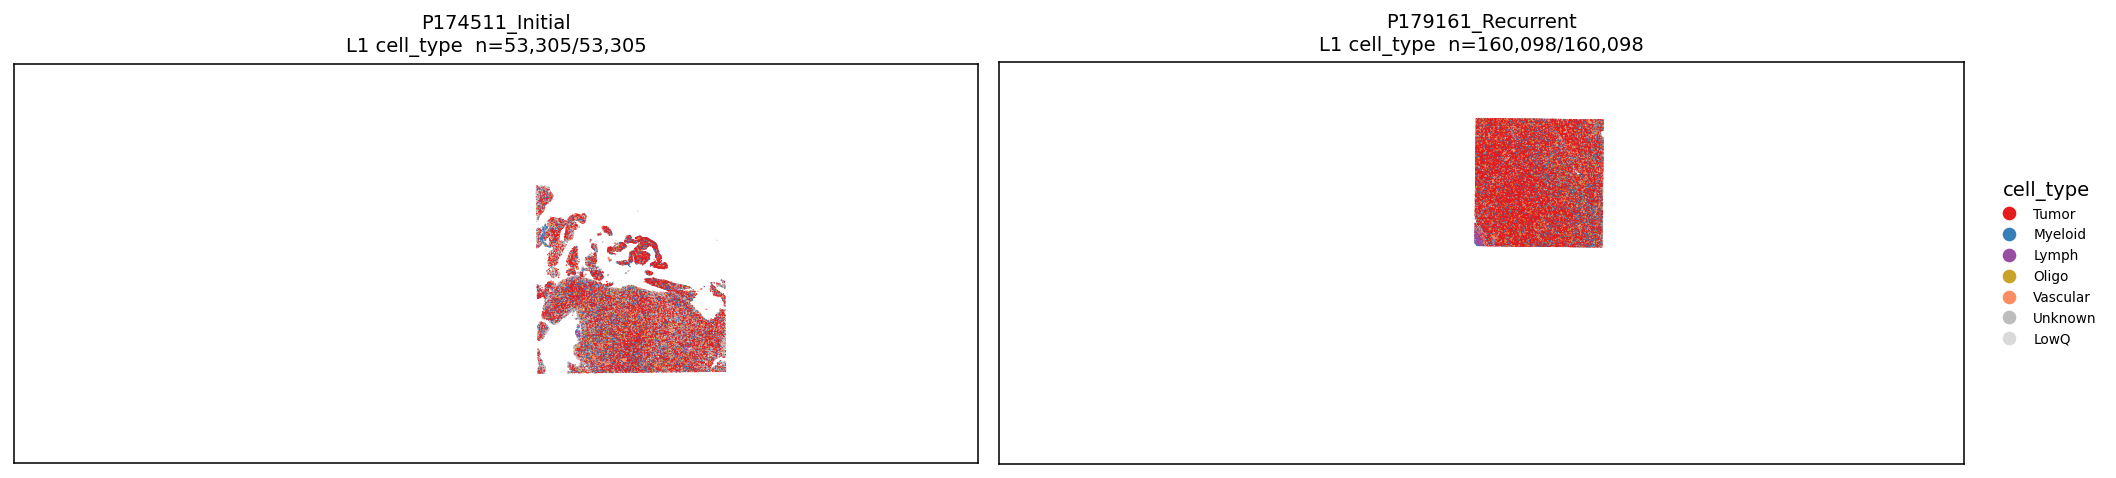

Saved /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/GBM/Results/figures/gbm_anno_xlsx_L1_cell_type_spatial.png


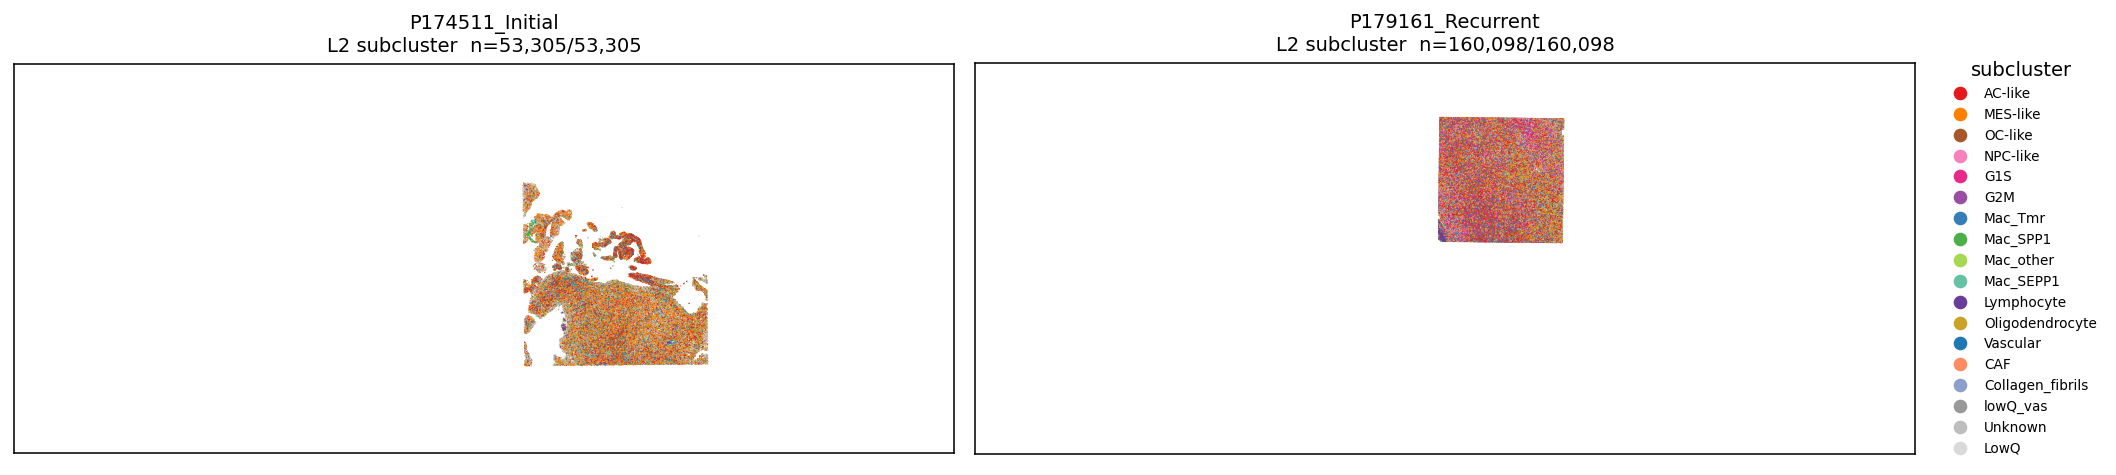

Saved /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/GBM/Results/figures/gbm_anno_xlsx_L2_subcluster_spatial.png


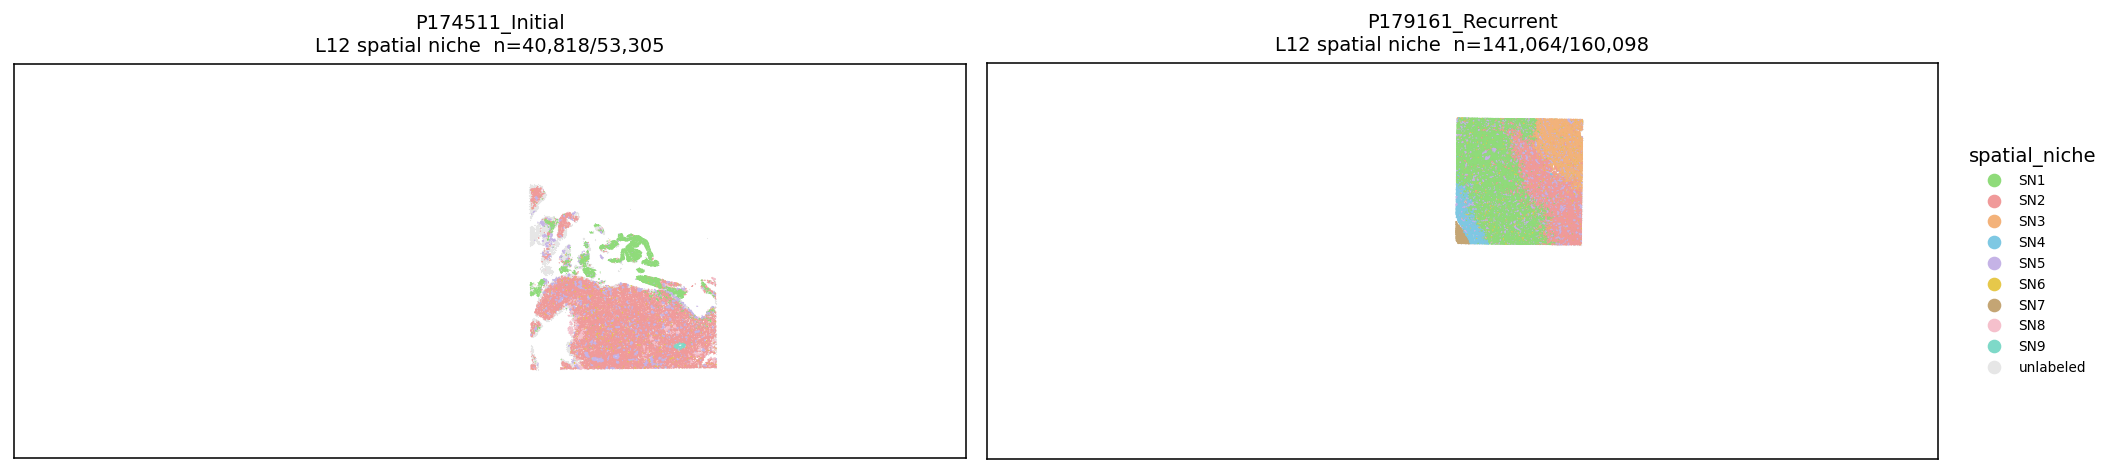

Saved /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/GBM/Results/figures/gbm_anno_xlsx_SN_spatial.png


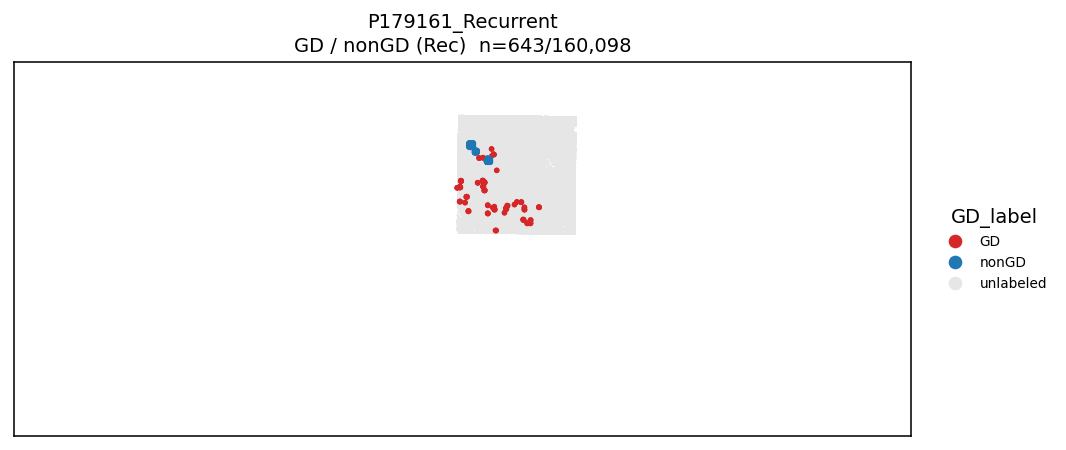

Saved /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/GBM/Results/figures/gbm_anno_xlsx_GD_spatial.png


PosixPath('/nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/GBM/Results/figures/gbm_anno_xlsx_GD_spatial.png')

In [7]:
def _label_key(value: object) -> str | None:
    if pd.isna(value):
        return None
    text = str(value).strip()
    return None if text in ("", "nan", "None") else text


def _ordered_labels(frames: dict, col: str, preferred: list[str] | None = None) -> list[str]:
    present = []
    seen = set()
    for df in frames.values():
        for value in df[col]:
            key = _label_key(value)
            if key and key not in seen:
                seen.add(key)
                present.append(key)
    if not preferred:
        return sorted(present)
    return [name for name in preferred if name in seen] + sorted(seen - set(preferred))


def _scatter_level(
    ax, df: pd.DataFrame, col: str, palette: dict, w: int, h: int,
    *, s: float = 0.35, s_labeled: float | None = None,
):
    xy = df.dropna(subset=["x", "y"])
    unlabeled = xy[xy[col].map(_label_key).isna()]
    labeled = xy[xy[col].map(_label_key).notna()]
    if len(unlabeled):
        ax.scatter(
            unlabeled["x"], unlabeled["y"], s=s, c=UNLABELED_COLOR,
            linewidths=0, rasterized=True, zorder=1,
        )
    s_lab = s if s_labeled is None else s_labeled
    if len(labeled):
        colors = labeled[col].map(lambda v: palette.get(_label_key(v), "#7f7f7f"))
        ax.scatter(
            labeled["x"], labeled["y"], s=s_lab, c=list(colors),
            linewidths=0, rasterized=True, zorder=2,
        )
    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def plot_annotation_level(
    frames: dict,
    col: str,
    palette: dict,
    title: str,
    out_name: str,
    *,
    preferred: list[str] | None = None,
    samples: list[str] | None = None,
    s: float = 0.35,
    s_labeled: float | None = None,
):
    samples = samples or list(frames)
    labels = _ordered_labels({k: frames[k] for k in samples}, col, preferred)
    n = len(samples)
    fig, axes = plt.subplots(1, n, figsize=(7.5 * n, 5.2), dpi=140, constrained_layout=True)
    if n == 1:
        axes = [axes]
    for ax, sample in zip(axes, samples):
        w, h = he_shape[sample]
        _scatter_level(ax, frames[sample], col, palette, w, h, s=s, s_labeled=s_labeled)
        n_lab = frames[sample][col].map(_label_key).notna().sum()
        ax.set_title(f"{sample}\n{title}  n={n_lab:,}/{len(frames[sample]):,}", fontsize=10)
    handles = [
        Line2D([0], [0], marker="o", linestyle="", color=palette.get(name, "#7f7f7f"),
               label=name, markersize=6)
        for name in labels
    ]
    if any(frames[s][col].map(_label_key).isna().any() for s in samples):
        handles.append(
            Line2D([0], [0], marker="o", linestyle="", color=UNLABELED_COLOR,
                   label="unlabeled", markersize=6)
        )
    axes[-1].legend(
        handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5),
        fontsize=7, title=col, frameon=False,
    )
    out = FIG_DIR / out_name
    fig.savefig(out, dpi=140, bbox_inches="tight")
    plt.show()
    print("Saved", out)
    return out


sn_order = [f"SN{i}" for i in range(1, 10)]
l1_order = ["Tumor", "Myeloid", "Lymph", "Oligo", "Vascular", "Unknown", "LowQ"]
l2_order = list(L2_COLORS)

plot_annotation_level(
    anno_xy, "cell_type", L1_COLORS, "L1 cell_type",
    "gbm_anno_xlsx_L1_cell_type_spatial.png", preferred=l1_order,
)
plot_annotation_level(
    anno_xy, "subcluster", L2_COLORS, "L2 subcluster",
    "gbm_anno_xlsx_L2_subcluster_spatial.png", preferred=l2_order,
)
sn_frames = {k: v.copy() for k, v in anno_xy.items()}
for _df in sn_frames.values():
    _df["spatial_niche"] = _df["spatial_niche"].map(fill_gbm_spatial_niche)
plot_annotation_level(
    sn_frames, "spatial_niche", SN_COLORS, "L12 spatial niche",
    "gbm_anno_xlsx_SN_spatial.png", preferred=sn_order,
)
plot_annotation_level(
    anno_xy, "GD_label", GD_COLORS, "GD / nonGD (Rec)",
    "gbm_anno_xlsx_GD_spatial.png", preferred=["GD", "nonGD"],
    samples=["P179161_Recurrent"], s=0.15, s_labeled=8.0,
)


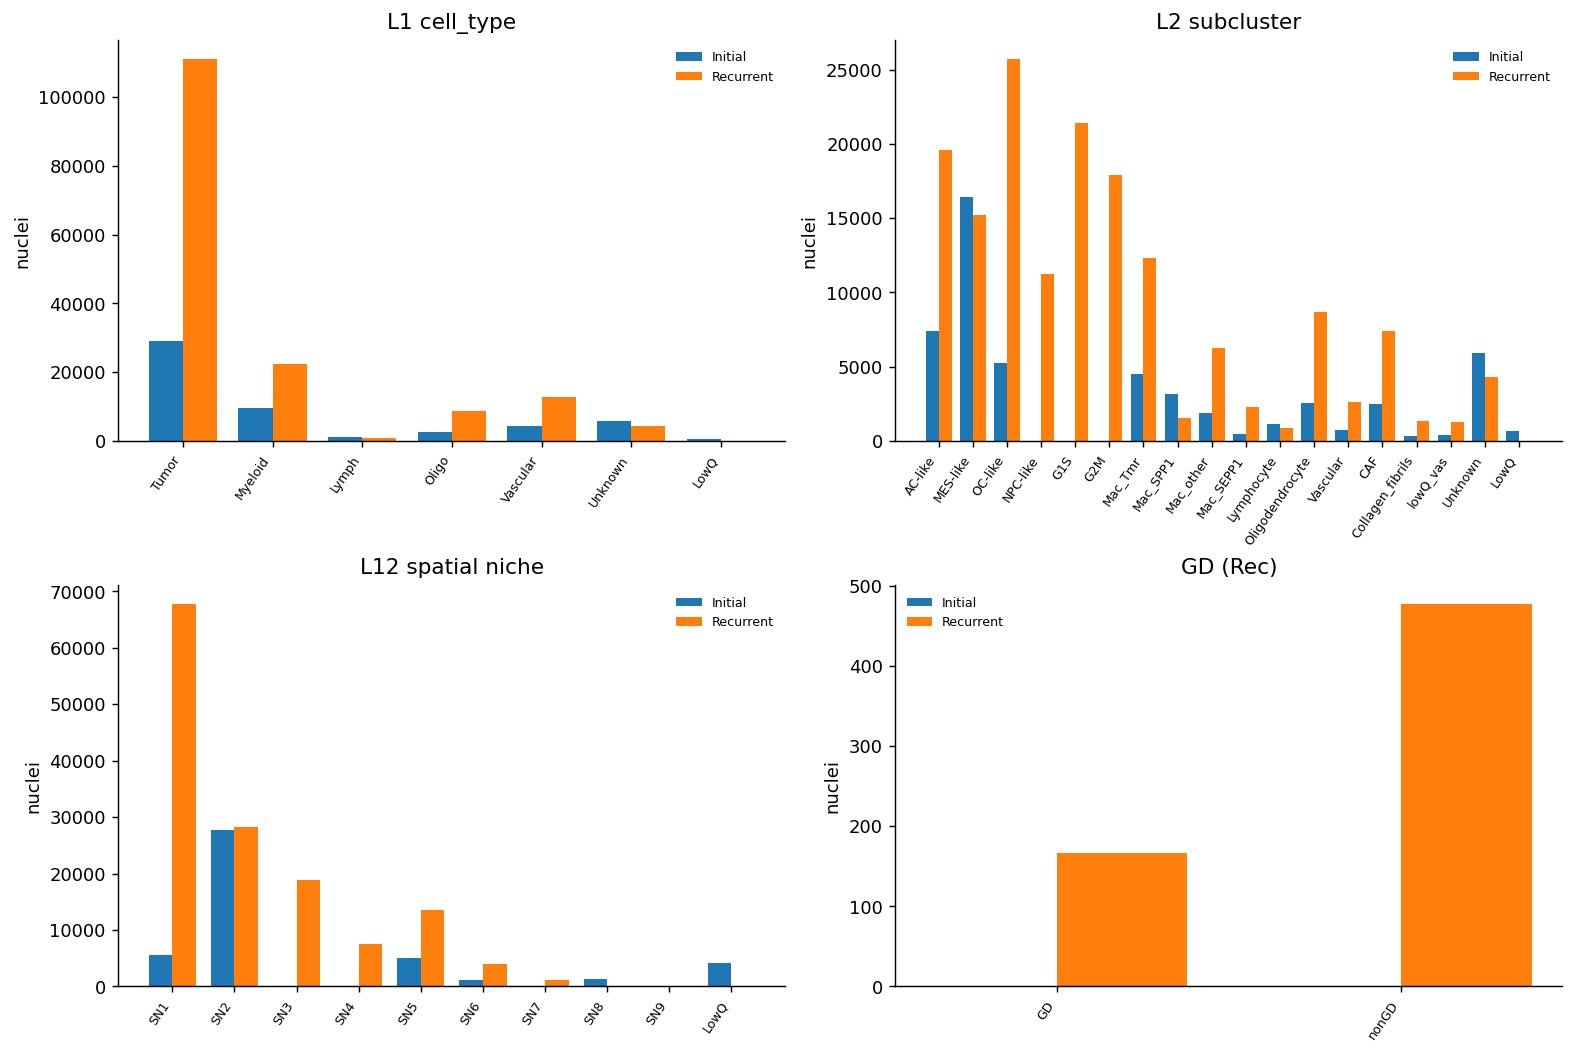

Saved /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/GBM/Results/figures/gbm_anno_xlsx_level_counts.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=130, constrained_layout=True)
count_specs = [
    ("cell_type", "L1 cell_type", l1_order),
    ("subcluster", "L2 subcluster", l2_order),
    ("spatial_niche", "L12 spatial niche", sn_order),
    ("GD_label", "GD (Rec)", ["GD", "nonGD"]),
]
for ax, (col, title, order) in zip(axes.ravel(), count_specs):
    rows = []
    for sample, df in anno_xy.items():
        vc = df[col].map(_label_key).value_counts(dropna=True)
        for name, n in vc.items():
            rows.append({"sample": sample, "label": name, "n": int(n)})
    counts = pd.DataFrame(rows)
    if counts.empty:
        ax.set_title(f"{title} (empty)")
        continue
    labels = [name for name in order if name in set(counts["label"])]
    labels += sorted(set(counts["label"]) - set(labels))
    x = np.arange(len(labels))
    width = 0.38
    for i, sample in enumerate(anno_xy):
        n_by = (
            counts.loc[counts["sample"] == sample]
            .set_index("label")["n"]
            .reindex(labels)
            .fillna(0)
        )
        ax.bar(x + (i - 0.5) * width, n_by.to_numpy(), width=width, label=sample.split("_")[-1])
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=55, ha="right", fontsize=7)
    ax.set_ylabel("nuclei")
    ax.set_title(title)
    ax.legend(fontsize=7, frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

count_path = FIG_DIR / "gbm_anno_xlsx_level_counts.png"
fig.savefig(count_path, dpi=130, bbox_inches="tight")
plt.show()
print("Saved", count_path)
